# Ablation Study — Readability Analysis

This notebook compares **Flesch Reading Ease (FRE)** and **Flesch-Kincaid Grade Level (FKGL)** scores across all ablation conditions:

| Condition | File |
|---|---|
| Beginner · LIME · **With Ontology** | `beginner_normal_lime.csv` |
| Beginner · LIME · **Without Ontology** | `beginner_no_ontology_lime.csv` |
| Beginner · IG · **With Ontology** | `beginner_normal_ig.csv` |
| Expert · LIME · **With Ontology** | `expert_normal_lime.csv` |
| Expert · LIME · **Without Ontology** | `expert_no_ontology_lime.csv` |
| Expert · IG · **With Ontology** | `expert_normal_ig.csv` |

> **Higher FRE** → easier to read. **Lower FKGL** → lower reading grade level required.


## 1 · Imports & Setup

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

# ── Aesthetics ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 140,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PALETTE = {
    'Beginner · LIME · With Ontology':    '#4C9BE8',
    'Beginner · LIME · Without Ontology': '#A8D0F5',
    'Beginner · IG · With Ontology':      '#2ECC71',
    'Expert · LIME · With Ontology':      '#E67E22',
    'Expert · LIME · Without Ontology':   '#F5C497',
    'Expert · IG · With Ontology':        '#9B59B6',
}

print('Ready.')

Ready.


## 2 · Load Data

In [2]:
# ── File → human-readable label mapping ──────────────────────────────────────
FILE_LABEL_MAP = {
    'beginner_normal_lime.csv':      'Beginner · LIME · With Ontology',
    'beginner_no_ontology_lime.csv': 'Beginner · LIME · Without Ontology',
    'beginner_normal_ig.csv':        'Beginner · IG · With Ontology',
    'expert_normal_lime.csv':        'Expert · LIME · With Ontology',
    'expert_no_ontology_lime.csv':   'Expert · LIME · Without Ontology',
    'expert_normal_ig.csv':          'Expert · IG · With Ontology',
}

# ── Load all CSVs from the same directory as this notebook ───────────────────
ABLATION_DIR = os.path.dirname(os.path.abspath('__file__'))  # notebook directory

frames = []
for fname, label in FILE_LABEL_MAP.items():
    fpath = os.path.join(ABLATION_DIR, fname)
    if not os.path.exists(fpath):
        print(f'[WARNING] Not found: {fpath}')
        continue
    df = pd.read_csv(fpath)
    df['condition'] = label
    frames.append(df)
    print(f'Loaded {fname:45s}  →  {len(df)} row(s)')

data = pd.concat(frames, ignore_index=True)

# Ensure numeric types
data['flesch_reading_ease']    = pd.to_numeric(data['flesch_reading_ease'],    errors='coerce')
data['flesch_kincaid_grade']   = pd.to_numeric(data['flesch_kincaid_grade'],   errors='coerce')

print(f'\nTotal rows loaded: {len(data)}')
print(f'Columns: {list(data.columns)}')

Loaded beginner_normal_lime.csv                       →  1 row(s)
Loaded beginner_no_ontology_lime.csv                  →  1 row(s)
Loaded beginner_normal_ig.csv                         →  1 row(s)
Loaded expert_normal_lime.csv                         →  1 row(s)
Loaded expert_no_ontology_lime.csv                    →  1 row(s)
Loaded expert_normal_ig.csv                           →  1 row(s)

Total rows loaded: 6
Columns: ['experiment_tag', 'xai_method', 'user_category', 'ablation_mode', 'constrained_decoding', 'lambda', 'ner_merging', 'predicted_class', 'confidence', 'text_snippet', 'explanation', 'lime_coverage', 'ontology_hit_rate', 'flesch_reading_ease', 'flesch_kincaid_grade', 'smog_index', 'condition']


## 3 · Summary Table

In [3]:
# ── Aggregate per condition ───────────────────────────────────────────────────
summary = (
    data
    .groupby('condition', sort=False)[['flesch_reading_ease', 'flesch_kincaid_grade']]
    .agg(['mean', 'std', 'min', 'max', 'count'])
)
summary.columns = ['_'.join(c) for c in summary.columns]
summary = summary.reset_index()

# Round for display
display_cols = {
    'condition':                         'Condition',
    'flesch_reading_ease_mean':          'FRE Mean',
    'flesch_reading_ease_std':           'FRE Std',
    'flesch_reading_ease_min':           'FRE Min',
    'flesch_reading_ease_max':           'FRE Max',
    'flesch_kincaid_grade_mean':         'FKGL Mean',
    'flesch_kincaid_grade_std':          'FKGL Std',
    'flesch_kincaid_grade_min':          'FKGL Min',
    'flesch_kincaid_grade_max':          'FKGL Max',
    'flesch_reading_ease_count':         'N Samples',
}
summary_display = summary[list(display_cols.keys())].rename(columns=display_cols)
summary_display = summary_display.round(2)

# Maintain desired order
label_order = list(FILE_LABEL_MAP.values())
summary_display['_order'] = summary_display['Condition'].map({v: i for i, v in enumerate(label_order)})
summary_display = summary_display.sort_values('_order').drop(columns='_order')

# Highlight best FRE (highest) and best FKGL (lowest) per audience
styled = (
    summary_display
    .style
    .set_caption('Readability Metrics Summary — Ablation Study')
    .highlight_max(subset=['FRE Mean'], color='#d4edda')   # green → easier to read
    .highlight_min(subset=['FKGL Mean'], color='#d4edda')  # green → lower grade level
    .highlight_min(subset=['FRE Mean'], color='#f8d7da')   # red → hardest to read
    .highlight_max(subset=['FKGL Mean'], color='#f8d7da')  # red → highest grade level
    .format(precision=2)
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '12px')]
    }])
)
display(styled)

,Condition,FRE Mean,FRE Std,FRE Min,FRE Max,FKGL Mean,FKGL Std,FKGL Min,FKGL Max,N Samples
0,Beginner · LIME · With Ontology,66.97,nan,66.97,66.97,8.54,nan,8.54,8.54,1
1,Beginner · LIME · Without Ontology,68.09,nan,68.09,68.09,8.27,nan,8.27,8.27,1
2,Beginner · IG · With Ontology,76.11,nan,76.11,76.11,5.93,nan,5.93,5.93,1
3,Expert · LIME · With Ontology,5.05,nan,5.05,5.05,19.82,nan,19.82,19.82,1
4,Expert · LIME · Without Ontology,9.52,nan,9.52,9.52,19.05,nan,19.05,19.05,1
5,Expert · IG · With Ontology,8.90,nan,8.90,8.90,19.72,nan,19.72,19.72,1


## 4 · Bar Charts: FRE and FKGL Side-by-Side

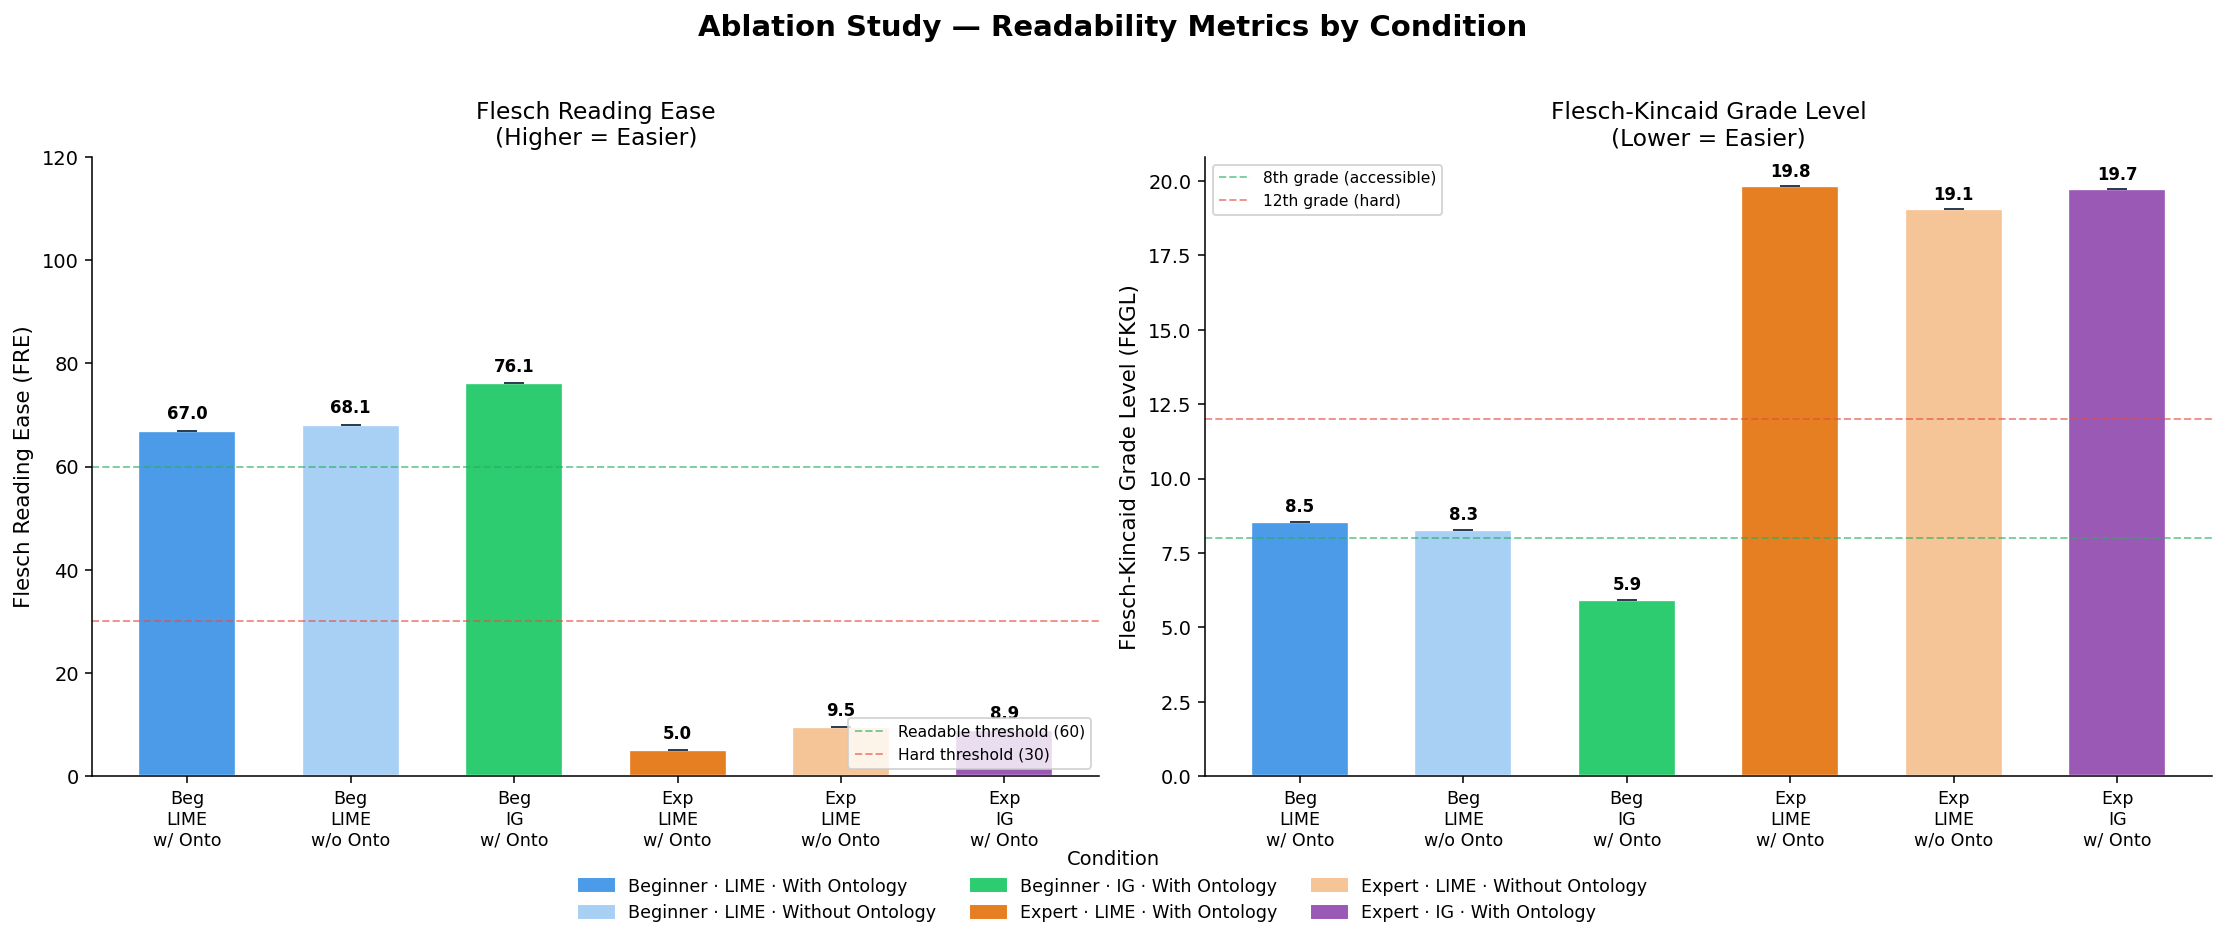

Figure saved to ablation_bar_chart.png


In [4]:
# Re-order summary rows to match label_order
summary_plot = summary_display.copy()
summary_plot['_order'] = summary_plot['Condition'].map({v: i for i, v in enumerate(label_order)})
summary_plot = summary_plot.sort_values('_order').reset_index(drop=True)

conditions = summary_plot['Condition'].tolist()
colors = [PALETTE[c] for c in conditions]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ablation Study — Readability Metrics by Condition', fontsize=15, fontweight='bold', y=1.02)

x = np.arange(len(conditions))
short_labels = [
    'Beg\nLIME\nw/ Onto',
    'Beg\nLIME\nw/o Onto',
    'Beg\nIG\nw/ Onto',
    'Exp\nLIME\nw/ Onto',
    'Exp\nLIME\nw/o Onto',
    'Exp\nIG\nw/ Onto',
]

# ── FRE ───────────────────────────────────────────────────────────────────────
ax1 = axes[0]
bars1 = ax1.bar(x, summary_plot['FRE Mean'], color=colors, edgecolor='white', linewidth=1.2, width=0.6)

# Error bars if std is available and >0
std_fre = summary_plot['FRE Std'].fillna(0)
ax1.errorbar(x, summary_plot['FRE Mean'], yerr=std_fre, fmt='none', color='#2c3e50', capsize=5, linewidth=1.5)

ax1.set_xticks(x)
ax1.set_xticklabels(short_labels, fontsize=9)
ax1.set_ylabel('Flesch Reading Ease (FRE)', fontsize=11)
ax1.set_title('Flesch Reading Ease\n(Higher = Easier)', fontsize=12)
ax1.set_ylim(0, 120)
ax1.axhline(y=60, color='#27ae60', linestyle='--', alpha=0.6, linewidth=1, label='Readable threshold (60)')
ax1.axhline(y=30, color='#e74c3c', linestyle='--', alpha=0.6, linewidth=1, label='Hard threshold (30)')
ax1.legend(fontsize=8, loc='lower right')

# Value labels
for bar, val in zip(bars1, summary_plot['FRE Mean']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# ── FKGL ──────────────────────────────────────────────────────────────────────
ax2 = axes[1]
bars2 = ax2.bar(x, summary_plot['FKGL Mean'], color=colors, edgecolor='white', linewidth=1.2, width=0.6)

std_fkgl = summary_plot['FKGL Std'].fillna(0)
ax2.errorbar(x, summary_plot['FKGL Mean'], yerr=std_fkgl, fmt='none', color='#2c3e50', capsize=5, linewidth=1.5)

ax2.set_xticks(x)
ax2.set_xticklabels(short_labels, fontsize=9)
ax2.set_ylabel('Flesch-Kincaid Grade Level (FKGL)', fontsize=11)
ax2.set_title('Flesch-Kincaid Grade Level\n(Lower = Easier)', fontsize=12)
ax2.axhline(y=8, color='#27ae60', linestyle='--', alpha=0.6, linewidth=1, label='8th grade (accessible)')
ax2.axhline(y=12, color='#e74c3c', linestyle='--', alpha=0.6, linewidth=1, label='12th grade (hard)')
ax2.legend(fontsize=8, loc='upper left')

for bar, val in zip(bars2, summary_plot['FKGL Mean']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f'{val:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# ── Legend patches ────────────────────────────────────────────────────────────
patches = [mpatches.Patch(color=PALETTE[c], label=c) for c in conditions]
fig.legend(handles=patches, bbox_to_anchor=(0.5, -0.08), loc='lower center',
           ncol=3, fontsize=9, frameon=False, title='Condition', title_fontsize=10)

plt.tight_layout()
plt.savefig('ablation_bar_chart.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved to ablation_bar_chart.png')

## 5 · Grouped Bar: Beginner vs Expert Comparison

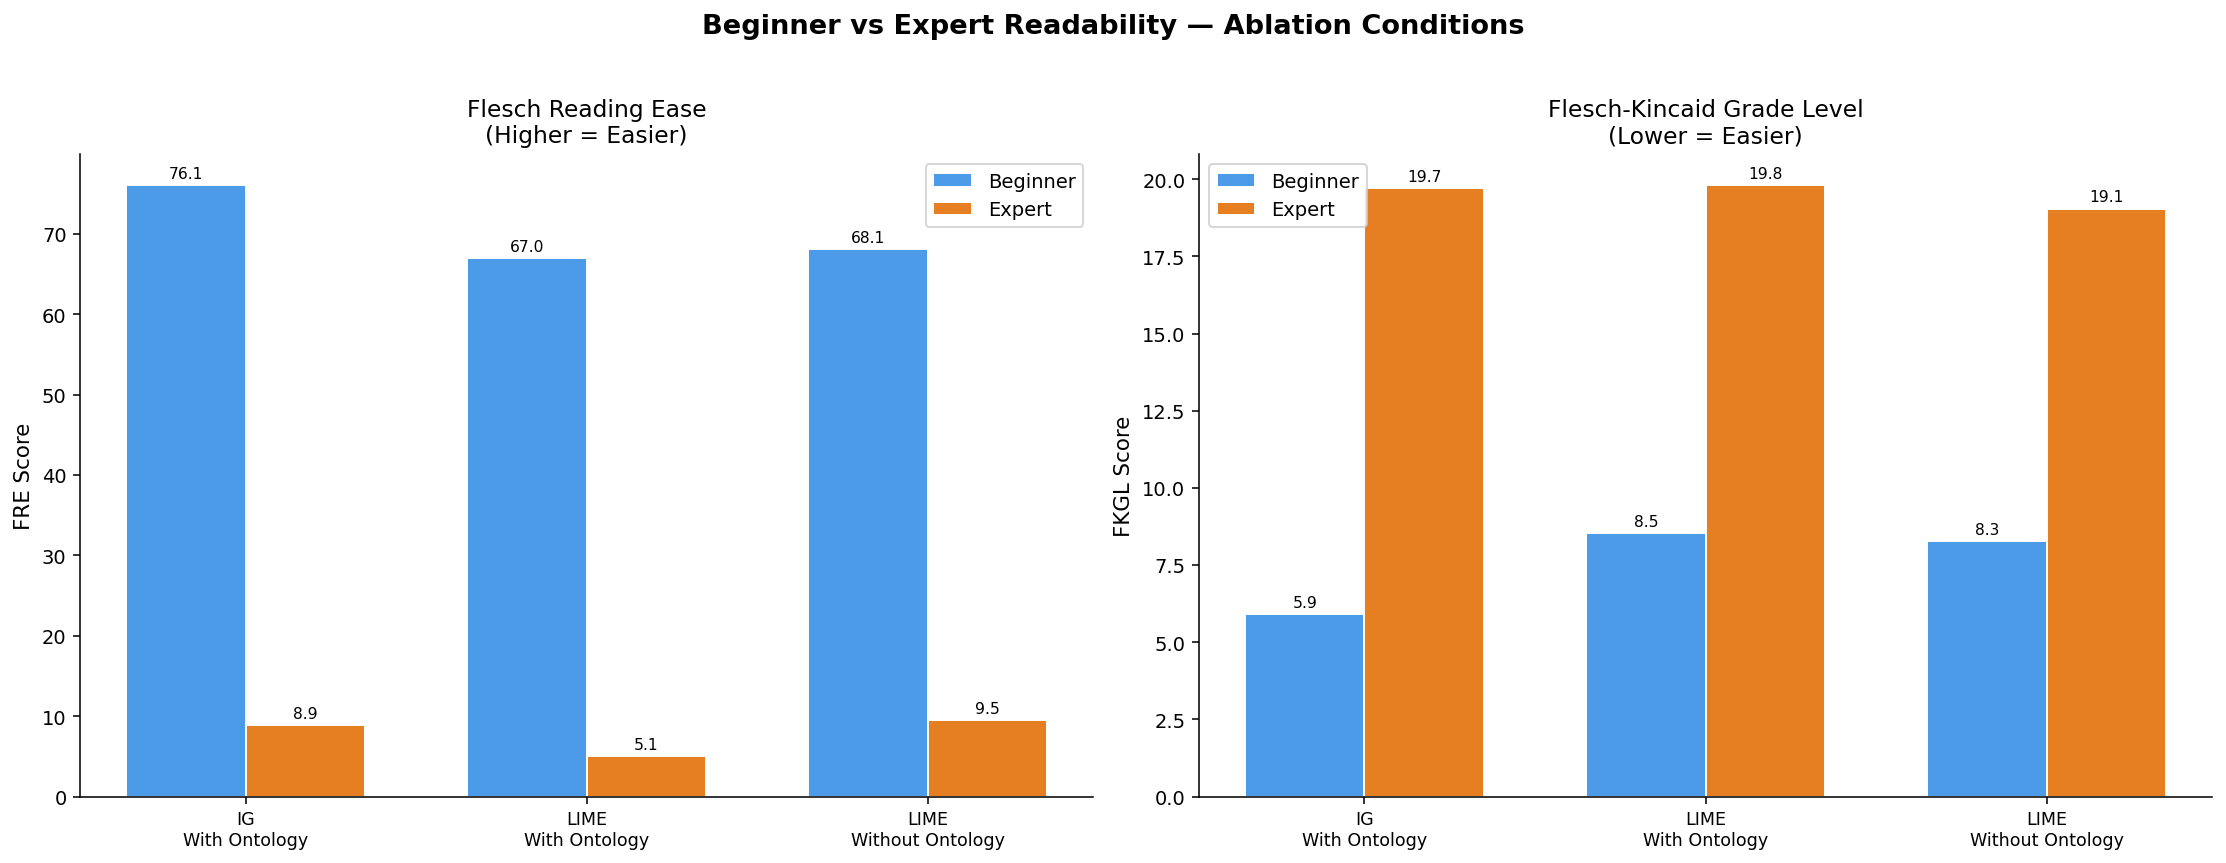

Figure saved to ablation_grouped_bar.png


In [5]:
# ── Group by (audience, xai_method, has_ontology) for cleaner grouped view ─
data['audience']    = data['user_category'].str.title()
data['xai']         = data['xai_method']
data['ontology']    = data['ablation_mode'].apply(lambda x: 'With Ontology' if x == 'normal' else 'Without Ontology')
data['group_label'] = data['xai'] + '\n' + data['ontology']

group_summary = (
    data
    .groupby(['audience', 'group_label'])[['flesch_reading_ease', 'flesch_kincaid_grade']]
    .mean()
    .reset_index()
)

# Pivot for grouped bar
fre_pivot  = group_summary.pivot(index='group_label', columns='audience', values='flesch_reading_ease')
fkgl_pivot = group_summary.pivot(index='group_label', columns='audience', values='flesch_kincaid_grade')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Beginner vs Expert Readability — Ablation Conditions', fontsize=14, fontweight='bold', y=1.02)

beg_color  = '#4C9BE8'
exp_color  = '#E67E22'

for ax, pivot, metric, title, ylabel, invert in [
    (axes[0], fre_pivot,  'FRE',  'Flesch Reading Ease\n(Higher = Easier)',  'FRE Score', False),
    (axes[1], fkgl_pivot, 'FKGL', 'Flesch-Kincaid Grade Level\n(Lower = Easier)', 'FKGL Score', False),
]:
    n_groups = len(pivot)
    x = np.arange(n_groups)
    w = 0.35

    cols = pivot.columns.tolist()
    if 'Beginner' in cols:
        b1 = ax.bar(x - w/2, pivot['Beginner'], w, label='Beginner', color=beg_color, edgecolor='white')
    if 'Expert' in cols:
        b2 = ax.bar(x + w/2, pivot['Expert'],   w, label='Expert',   color=exp_color, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index.tolist(), fontsize=9)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)

    # Value labels
    for bars in ax.containers:
        ax.bar_label(bars, fmt='%.1f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('ablation_grouped_bar.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved to ablation_grouped_bar.png')

## 6 · Ontology Ablation: Effect on FRE & FKGL

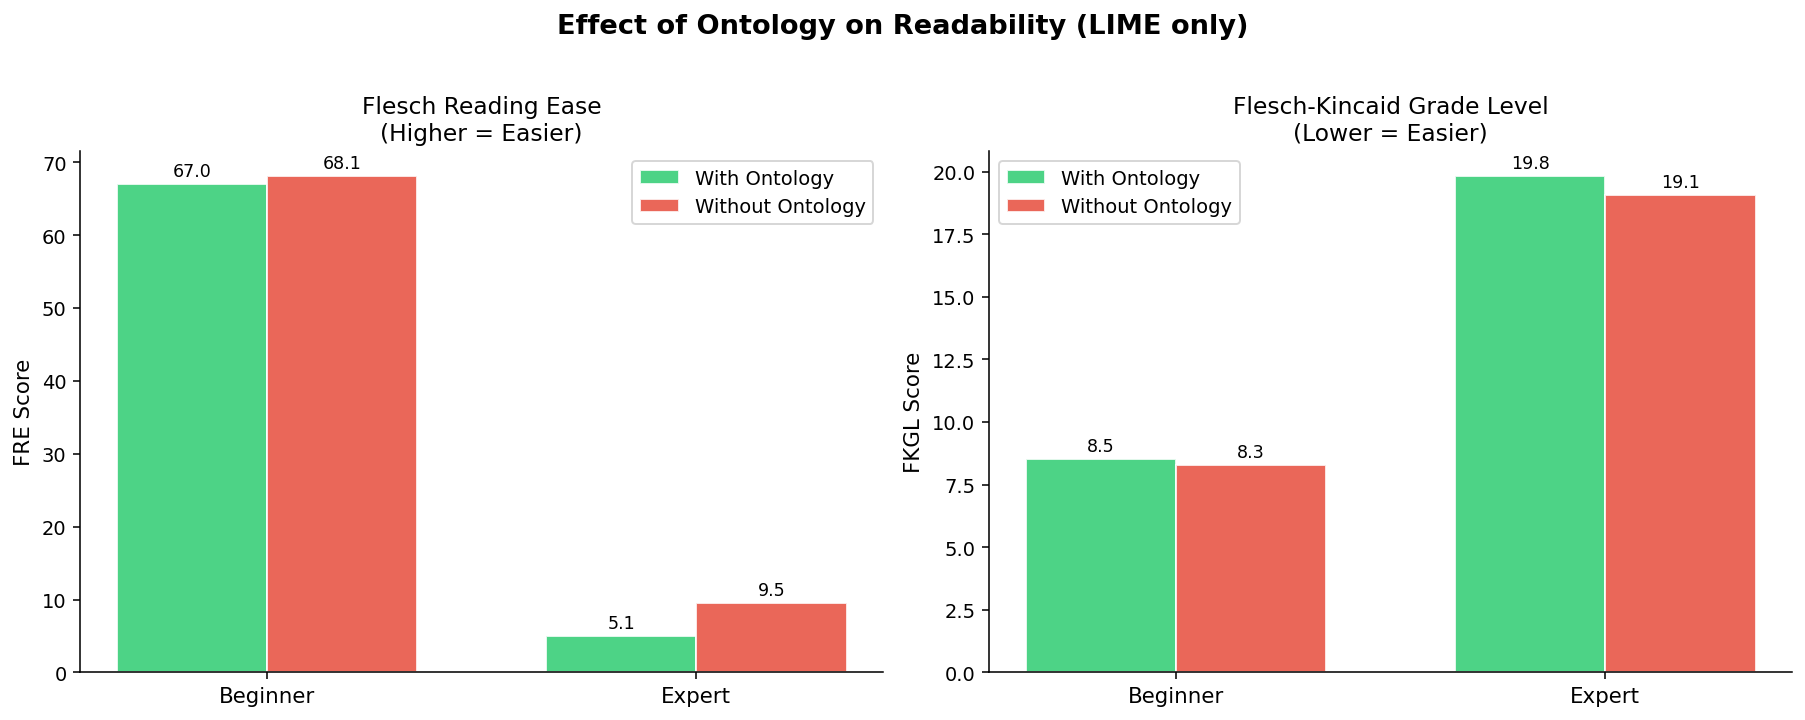

Figure saved to ablation_ontology_effect.png


In [6]:
# ── Only LIME rows have a no_ontology variant — compare with/without ─────────
lime_data = data[data['xai_method'] == 'LIME'].copy()
onto_summary = (
    lime_data
    .groupby(['audience', 'ontology'])[['flesch_reading_ease', 'flesch_kincaid_grade']]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Effect of Ontology on Readability (LIME only)', fontsize=14, fontweight='bold', y=1.02)

onto_colors = {'With Ontology': '#2ecc71', 'Without Ontology': '#e74c3c'}

audiences = onto_summary['audience'].unique()
x = np.arange(len(audiences))
w = 0.35

for ax, metric, ylabel, title in [
    (axes[0], 'flesch_reading_ease',  'FRE Score',  'Flesch Reading Ease\n(Higher = Easier)'),
    (axes[1], 'flesch_kincaid_grade', 'FKGL Score', 'Flesch-Kincaid Grade Level\n(Lower = Easier)'),
]:
    for i, (onto_val, color) in enumerate([('With Ontology', '#2ecc71'), ('Without Ontology', '#e74c3c')]):
        subset = onto_summary[onto_summary['ontology'] == onto_val]
        vals = [subset[subset['audience'] == a][metric].values[0] if len(subset[subset['audience'] == a]) > 0 else 0
                for a in audiences]
        offset = (i - 0.5) * w
        bars = ax.bar(x + offset, vals, w, label=onto_val, color=color, edgecolor='white', alpha=0.85)
        ax.bar_label(bars, fmt='%.1f', fontsize=9, padding=2)

    ax.set_xticks(x)
    ax.set_xticklabels(audiences, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('ablation_ontology_effect.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved to ablation_ontology_effect.png')

## 7 · XAI Method Comparison: LIME vs IG

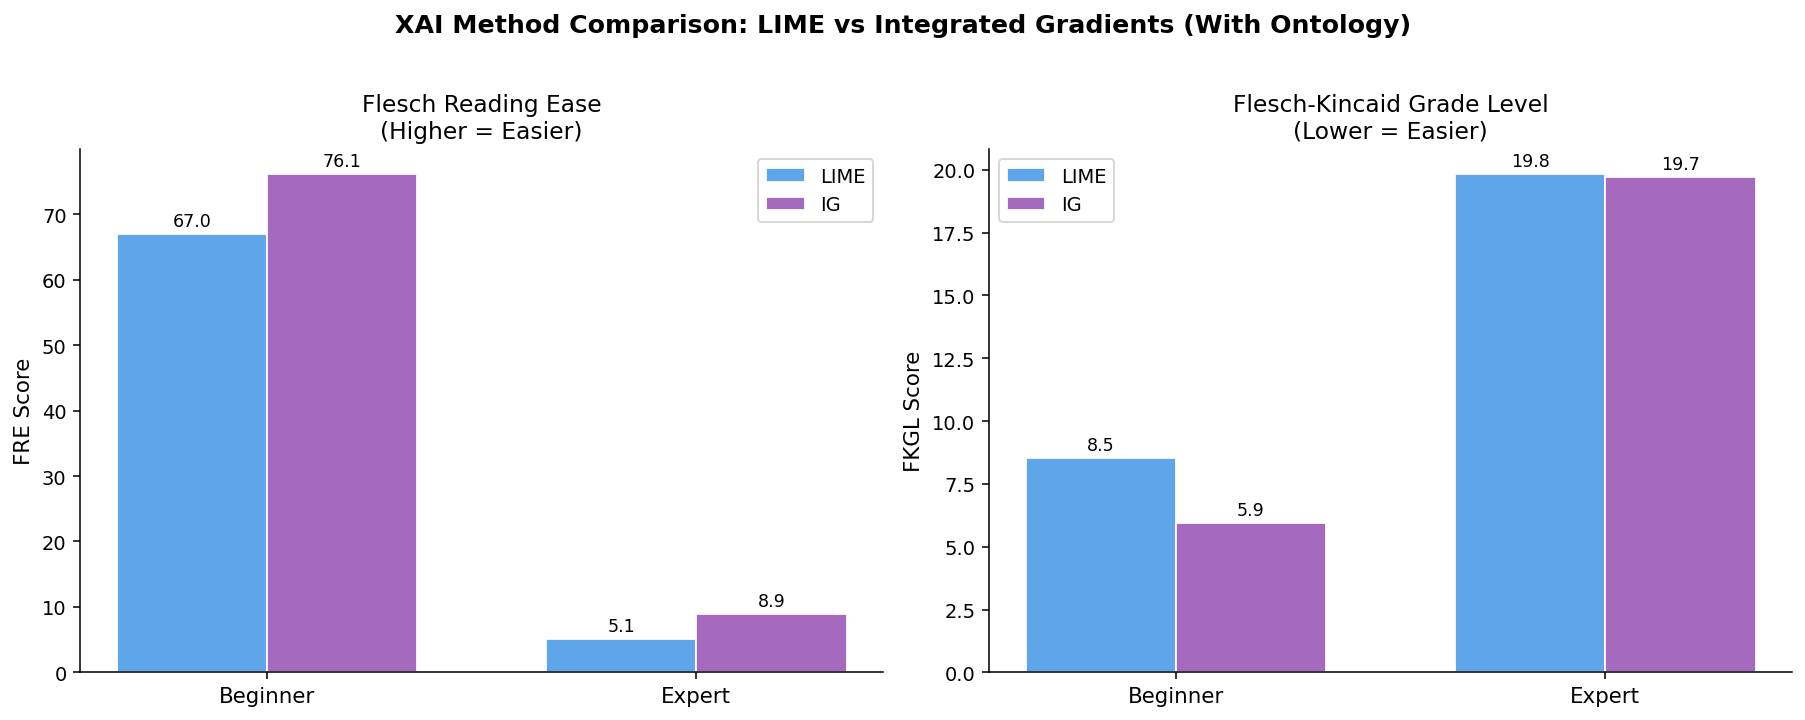

Figure saved to ablation_xai_method.png


In [7]:
# ── Compare LIME (with ontology) vs IG (with ontology) per audience ───────────
method_data = data[data['ablation_mode'] == 'normal'].copy()
method_summary = (
    method_data
    .groupby(['audience', 'xai'])[['flesch_reading_ease', 'flesch_kincaid_grade']]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('XAI Method Comparison: LIME vs Integrated Gradients (With Ontology)', fontsize=13, fontweight='bold', y=1.02)

xai_colors = {'LIME': '#4C9BE8', 'IG': '#9B59B6'}
audiences  = method_summary['audience'].unique()
x = np.arange(len(audiences))
w = 0.35

for ax, metric, ylabel, title in [
    (axes[0], 'flesch_reading_ease',  'FRE Score',  'Flesch Reading Ease\n(Higher = Easier)'),
    (axes[1], 'flesch_kincaid_grade', 'FKGL Score', 'Flesch-Kincaid Grade Level\n(Lower = Easier)'),
]:
    for i, (xai_val, color) in enumerate(xai_colors.items()):
        subset = method_summary[method_summary['xai'] == xai_val]
        vals = [subset[subset['audience'] == a][metric].values[0] if len(subset[subset['audience'] == a]) > 0 else 0
                for a in audiences]
        offset = (i - 0.5) * w
        bars = ax.bar(x + offset, vals, w, label=xai_val, color=color, edgecolor='white', alpha=0.9)
        ax.bar_label(bars, fmt='%.1f', fontsize=9, padding=2)

    ax.set_xticks(x)
    ax.set_xticklabels(audiences, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('ablation_xai_method.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved to ablation_xai_method.png')

## 8 · Radar / Spider Chart — All Conditions at a Glance

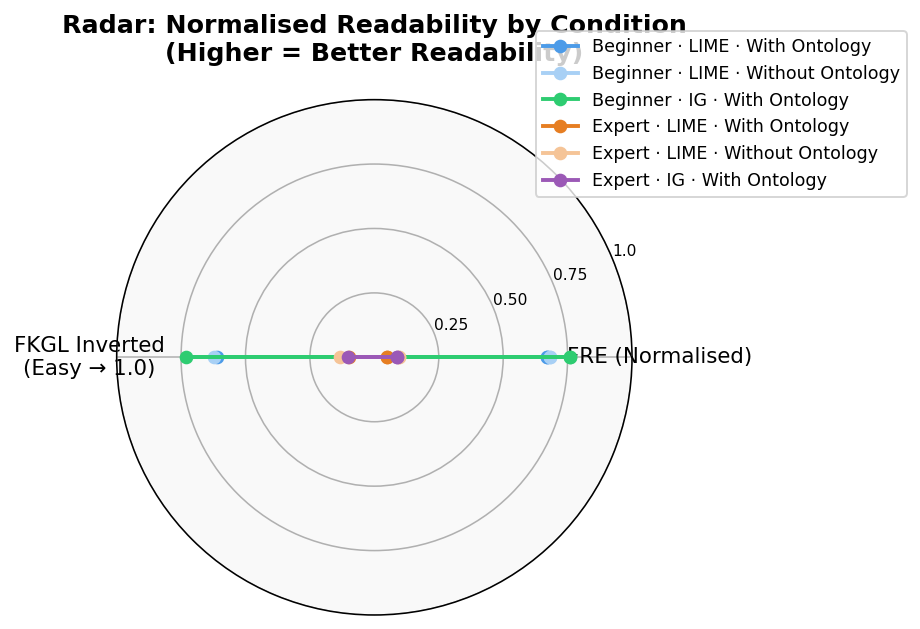

Figure saved to ablation_radar.png


In [8]:
# ── Normalise metrics to [0, 1] for radar display ────────────────────────────
# FRE: already 0-100+ → normalise within observed range (higher is better)
# FKGL: invert so that lower grade = higher score on chart (easier = higher)

metrics_for_radar = ['FRE Mean', 'FKGL Mean']
radar_df = summary_plot[['Condition', 'FRE Mean', 'FKGL Mean', 'N Samples']].copy()

# Normalise FRE: 0-100 scale, clamp
radar_df['FRE_norm']  = (radar_df['FRE Mean'].clip(0, 100)) / 100.0
# FKGL: invert and normalise (assuming range 0-22)
radar_df['FKGL_norm'] = 1 - (radar_df['FKGL Mean'].clip(0, 22) / 22.0)

categories = ['FRE (Normalised)', 'FKGL Inverted\n(Easy → 1.0)']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor('#f9f9f9')

for _, row in radar_df.iterrows():
    values = [row['FRE_norm'], row['FKGL_norm']]
    values += values[:1]
    color = PALETTE[row['Condition']]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Condition'], color=color)
    ax.fill(angles, values, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.0'], fontsize=8)
ax.set_title('Radar: Normalised Readability by Condition\n(Higher = Better Readability)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.55, 1.15), fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('ablation_radar.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved to ablation_radar.png')

## 9 · Key Observations (Auto-generated)

In [9]:
best_fre  = summary_plot.loc[summary_plot['FRE Mean'].idxmax()]
worst_fre = summary_plot.loc[summary_plot['FRE Mean'].idxmin()]
best_fkgl = summary_plot.loc[summary_plot['FKGL Mean'].idxmin()]
worst_fkgl= summary_plot.loc[summary_plot['FKGL Mean'].idxmax()]

# Delta: ontology effect on LIME (beginner)
beg_lime_onto    = summary_plot[summary_plot['Condition'] == 'Beginner · LIME · With Ontology']['FRE Mean'].values[0]
beg_lime_noonto  = summary_plot[summary_plot['Condition'] == 'Beginner · LIME · Without Ontology']['FRE Mean'].values[0]
exp_lime_onto    = summary_plot[summary_plot['Condition'] == 'Expert · LIME · With Ontology']['FRE Mean'].values[0]
exp_lime_noonto  = summary_plot[summary_plot['Condition'] == 'Expert · LIME · Without Ontology']['FRE Mean'].values[0]

print('=' * 65)
print('  ABLATION STUDY — KEY OBSERVATIONS')
print('=' * 65)
print(f'\n📈 Highest FRE (easiest to read):')
print(f'   → {best_fre["Condition"]}  (FRE = {best_fre["FRE Mean"]:.2f})')

print(f'\n📉 Lowest FRE (hardest to read):')
print(f'   → {worst_fre["Condition"]}  (FRE = {worst_fre["FRE Mean"]:.2f})')

print(f'\n🎓 Lowest FKGL (most accessible grade level):')
print(f'   → {best_fkgl["Condition"]}  (FKGL = {best_fkgl["FKGL Mean"]:.2f})')

print(f'\n🎓 Highest FKGL (hardest grade level):')
print(f'   → {worst_fkgl["Condition"]}  (FKGL = {worst_fkgl["FKGL Mean"]:.2f})')

print(f'\n🔬 Ontology Effect on LIME:')
print(f'   Beginner: With Ontology FRE={beg_lime_onto:.2f}, Without={beg_lime_noonto:.2f}  (Δ = {beg_lime_onto - beg_lime_noonto:+.2f})')
print(f'   Expert:   With Ontology FRE={exp_lime_onto:.2f}, Without={exp_lime_noonto:.2f}  (Δ = {exp_lime_onto - exp_lime_noonto:+.2f})')

# LIME vs IG
beg_lime_fre = summary_plot[summary_plot['Condition'] == 'Beginner · LIME · With Ontology']['FRE Mean'].values[0]
beg_ig_fre   = summary_plot[summary_plot['Condition'] == 'Beginner · IG · With Ontology']['FRE Mean'].values[0]
exp_lime_fre = summary_plot[summary_plot['Condition'] == 'Expert · LIME · With Ontology']['FRE Mean'].values[0]
exp_ig_fre   = summary_plot[summary_plot['Condition'] == 'Expert · IG · With Ontology']['FRE Mean'].values[0]

print(f'\n⚡ LIME vs IG (With Ontology):')
print(f'   Beginner: LIME FRE={beg_lime_fre:.2f}, IG FRE={beg_ig_fre:.2f}  (Δ = {beg_ig_fre - beg_lime_fre:+.2f})')
print(f'   Expert:   LIME FRE={exp_lime_fre:.2f}, IG FRE={exp_ig_fre:.2f}   (Δ = {exp_ig_fre - exp_lime_fre:+.2f})')
print('\n' + '=' * 65)

  ABLATION STUDY — KEY OBSERVATIONS

📈 Highest FRE (easiest to read):
   → Beginner · IG · With Ontology  (FRE = 76.11)

📉 Lowest FRE (hardest to read):
   → Expert · LIME · With Ontology  (FRE = 5.05)

🎓 Lowest FKGL (most accessible grade level):
   → Beginner · IG · With Ontology  (FKGL = 5.93)

🎓 Highest FKGL (hardest grade level):
   → Expert · LIME · With Ontology  (FKGL = 19.82)

🔬 Ontology Effect on LIME:
   Beginner: With Ontology FRE=66.97, Without=68.09  (Δ = -1.12)
   Expert:   With Ontology FRE=5.05, Without=9.52  (Δ = -4.47)

⚡ LIME vs IG (With Ontology):
   Beginner: LIME FRE=66.97, IG FRE=76.11  (Δ = +9.14)
   Expert:   LIME FRE=5.05, IG FRE=8.90   (Δ = +3.85)



## 10 · Export Full Summary Table to CSV

In [10]:
out_path = 'ablation_readability_summary.csv'
summary_display.drop(columns=['_order'], errors='ignore').to_csv(out_path, index=False)
print(f'Summary table saved to: {out_path}')
display(summary_display)

Summary table saved to: ablation_readability_summary.csv


,Condition,FRE Mean,FRE Std,FRE Min,FRE Max,FKGL Mean,FKGL Std,FKGL Min,FKGL Max,N Samples
0,Beginner · LIME · With Ontology,66.97,NaN,66.97,66.97,8.54,NaN,8.54,8.54,1
1,Beginner · LIME · Without Ontology,68.09,NaN,68.09,68.09,8.27,NaN,8.27,8.27,1
2,Beginner · IG · With Ontology,76.11,NaN,76.11,76.11,5.93,NaN,5.93,5.93,1
3,Expert · LIME · With Ontology,5.05,NaN,5.05,5.05,19.82,NaN,19.82,19.82,1
4,Expert · LIME · Without Ontology,9.52,NaN,9.52,9.52,19.05,NaN,19.05,19.05,1
5,Expert · IG · With Ontology,8.90,NaN,8.90,8.90,19.72,NaN,19.72,19.72,1
